In [29]:
using ITensors, ITensorMPS
using SparseArrays
using LinearAlgebra
using Plots
using JLD2
using LaTeXStrings
using Glob
using StatsBase

In [426]:
using JLD2
using Glob

"""
Load sample_*.jld2 files from `outdir` and combine data across
samples and repeated jobs.

Files missing required keys (including "mode") are skipped.

Returns:
  combined :: Dict{NamedTuple, Dict{Symbol, Any}}
  skipped  :: Vector{String}
"""
function load_and_combine(outdir::String)
    files = glob("sample_*20251231*.jld2", outdir)
    # files = glob("sample_*.jld2", outdir)

    combined = Dict{NamedTuple, Dict{Symbol, Any}}()
    skipped  = String[]

    for f in files
        d = load(f)

        # hard requirements
        if !(haskey(d, "L") &&
             haskey(d, "T") &&
             haskey(d, "p") &&
             haskey(d, "mode") &&
             haskey(d, "data"))
            push!(skipped, f)
            continue
        end

        # optional but expected
        t = get(d, "t", 1)

        key = (
            L    = d["L"],
            T    = d["T"],
            p    = d["p"],
            mode = d["mode"],
            t    = t,
        )

        data = d["data"]  # Dict or NamedTuple

        if !haskey(combined, key)
            combined[key] = Dict(
                obs => deepcopy(val) for (obs, val) in pairs(data)
            )
        else
            for (obs, val) in pairs(data)
                old = combined[key][obs]

                if isa(old, AbstractArray) && isa(val, AbstractArray)
                    combined[key][obs] = vcat(old, val)
                else
                    error("Cannot combine observable $obs in file $f")
                end
            end
        end
    end

    return combined, skipped
end

# Example usage
outdir = joinpath(@__DIR__, "../output")
combined, skipped = load_and_combine(outdir)

@show length(skipped)


length(skipped) = 0


0

In [429]:
using JLD2
using Glob

"""
Load sample_*.jld2 files from `outdir` and combine data across
samples and repeated jobs.

Files missing required keys (including "mode") are skipped.

Returns:
  combined :: Dict{NamedTuple, Dict{Symbol, Any}}
  skipped  :: Vector{String}
"""
function load_and_combine(outdir::String)
    # files = glob("sample_*20251231*.jld2", outdir)
    files = glob("sample_*TCI*.jld2", outdir)

    # combined = Dict{NamedTuple, Dict{Symbol, Any}}()
    # skipped  = String[]

    for f in files
        d = load(f)

        # hard requirements
        if !(haskey(d, "L") &&
             haskey(d, "T") &&
             haskey(d, "p") &&
             haskey(d, "mode") &&
             haskey(d, "data"))
            push!(skipped, f)
            continue
        end

        # optional but expected
        t = get(d, "t", 1)

        key = (
            L    = d["L"],
            T    = d["T"],
            p    = d["p"],
            mode = d["mode"],
            t    = t,
        )

        data = d["data"]  # Dict or NamedTuple

        if !haskey(combined, key)
            combined[key] = Dict(
                obs => deepcopy(val) for (obs, val) in pairs(data)
            )
        else
            for (obs, val) in pairs(data)
                old = combined[key][obs]

                if isa(old, AbstractArray) && isa(val, AbstractArray)
                    combined[key][obs] = vcat(old, val)
                else
                    error("Cannot combine observable $obs in file $f")
                end
            end
        end
    end

    return combined, skipped
end

# Example usage
outdir = joinpath(@__DIR__, "../output")
combined, skipped = load_and_combine(outdir)

@show length(skipped)


length(skipped) = 0


0

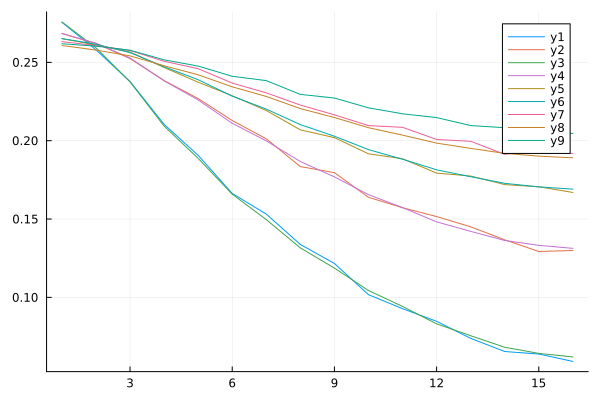

In [444]:
L = 32
T = 10L
p = 0.1
plot!(reverse(mean(combined[(L=L, T=T, p=p, mode="renyi1_sampled", t=5L)][:κ1_corrs_sampled], dims=1)[1,:]))

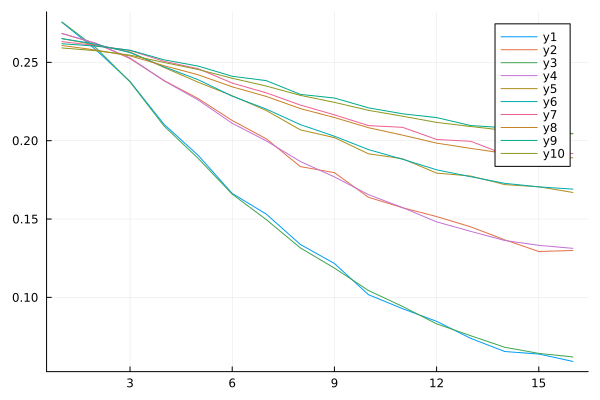

In [445]:
L = 32
T = 10L
p = 0.1
plot!(reverse(mean(combined[(L=L, T=T, p=p, mode="renyi1_TCI", t=5L)][:κ1_corrs_TCI], dims=1)[1,:]))

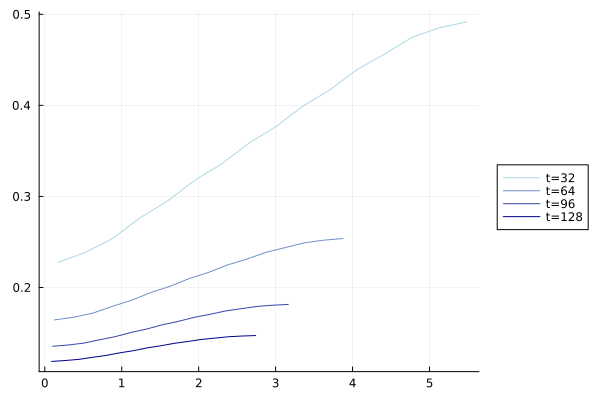

In [450]:
# which_ind(t) = t==0 ? 1 : t==1 ? 2 : t÷10+2
which_ind(t) = t÷10 + 1

p = 0.1

L = 32
T = 10L

ts = L:L:4L

colors = palette(:blues, length(ts))
plt = plot()
for (i, t) in enumerate(ts)
    ind = which_ind(t)
    xs = collect(1:2:L)
    xs /= sqrt(t)
    ys = reverse(mean(combined[(L=L, T=T, p=p, mode="renyi1_TCI", t=t)][:κ1_corrs_TCI], dims=1)[1,:])
    ys = -log.(ys)/sqrt(t)
    plot!(plt, xs, ys, label="t=$t",legend=:outerright,color=colors[i])#, xlims=(0,20), ylims=(-2,80))
end
plt

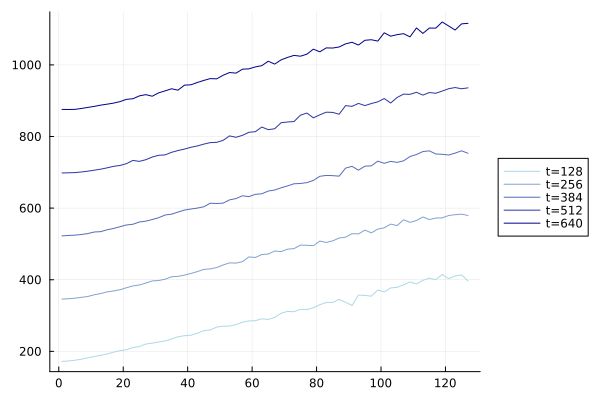

In [460]:
# which_ind(t) = t==0 ? 1 : t==1 ? 2 : t÷10+2
which_ind(t) = t÷10 + 1

p = 0.1

L = 128
T = 10L

ts = L:L:5L

colors = palette(:blues, length(ts))
plt = plot()
for (i, t) in enumerate(ts)
    ind = which_ind(t)
    xs = collect(1:2:L)
    # xs /= sqrt(t)
    ys = reverse(mean(combined[(L=L, T=T, p=p, mode="renyi1_sampled", t=t)][:κ1_corrs_sampled], dims=1)[1,:])
    ys = -t*log.(ys)
    plot!(plt, xs, ys, label="t=$t",legend=:outerright,color=colors[i])#, xlims=(0,20), ylims=(-2,80))
end
plt

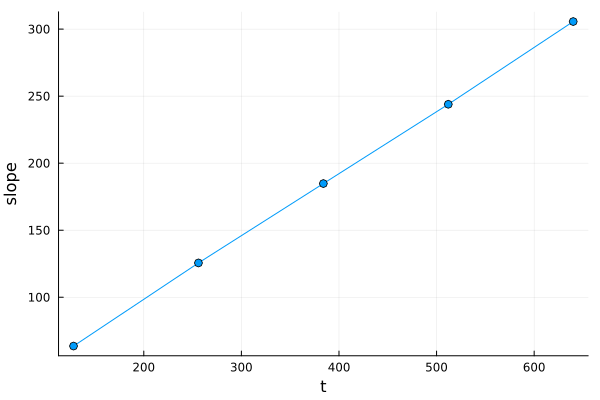

In [466]:
p = 0.1
L = 128
T = 10L
ts = L:L:5L

slopes = Float64[]
for t in ts
    ind = which_ind(t)
    xs = collect(1:2:L)
    ys_raw = reverse(mean(combined[(L=L, T=T, p=p, mode="renyi1_sampled", t=t)][:κ1_corrs_sampled], dims=1)[1,:])
    ys = -log.(ys_raw)

    mask = (xs .>= 0) .& (xs .<= L)
    X = hcat(xs[mask], ones(sum(mask)))
    β = X \ ys[mask]          # [slope, intercept]
    push!(slopes, 1/β[1])
end

plot(ts, slopes; xlabel="t", ylabel="slope", marker=:o, legend=false)

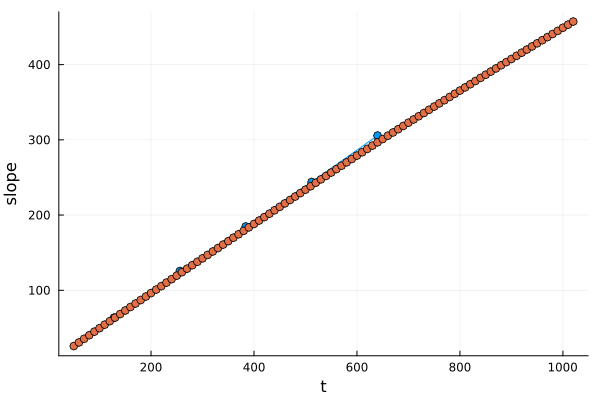

In [467]:
p = 0.1
L = 512
T = 10L
ts = 50:10:2L

slopes = Float64[]
for t in ts
    ind = which_ind(t)
    xs = collect(1:2:L)/sqrt(t)
    ys_raw = reverse(combined[(L=L, T=T, p=p, mode="renyi2", t=1)][:κ2_corrs][ind, :])
    ys = -log.(ys_raw)/sqrt(t)

    mask = (xs .>= 1) .& (xs .<= 3L/4/sqrt(t))
    X = hcat(xs[mask], ones(sum(mask)))
    β = X \ ys[mask]          # [slope, intercept]
    push!(slopes, 1/β[1])
end

plot!(ts, 2slopes; xlabel="t", ylabel="slope", marker=:o, legend=false)

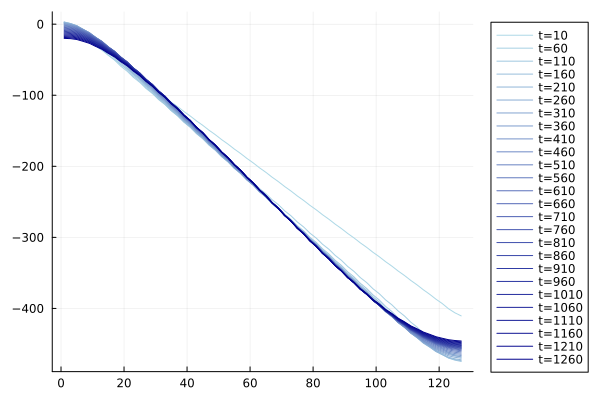

In [470]:
# which_ind(t) = t==0 ? 1 : t==1 ? 2 : t÷10+2
which_ind(t) = t÷10 + 1

p = 0.1

L = 128
T = 10L

ts = 10:50:1280

colors = palette(:blues, length(ts))
plt = plot()
for (i, t) in enumerate(ts)
    ind = which_ind(t)
    xs = 1:2:L
    ys = reverse(combined[(L=L, T=T, p=p, mode="renyi2", t=1)][:κ2_corrs][ind, :] )
    ys = t*log.(exp(1.35)*ys)
    plot!(plt, xs, ys, label="t=$t",legend=:outerright,color=colors[i])
end
plt

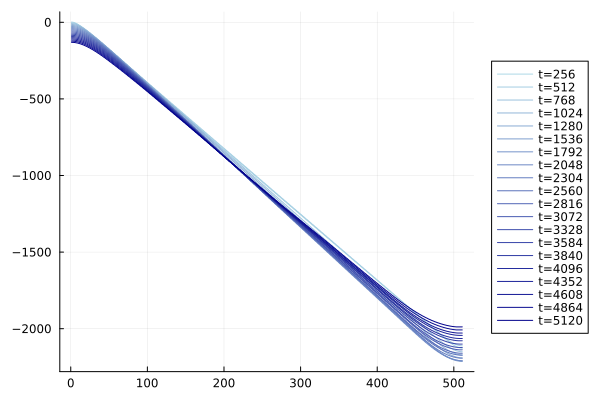

In [36]:
# which_ind(t) = t==0 ? 1 : t==1 ? 2 : t÷10+2
which_ind(t) = t÷10 + 1

p = 0.1

L = 512
T = 10L

ts = L÷2:L÷2:10L

colors = palette(:blues, length(ts))
plt = plot()
for (i, t) in enumerate(ts)
    ind = which_ind(t)
    xs = 1:2:L
    ys = reverse(combined[(L=L, T=T, p=p, mode="renyi2", t=1)][:κ2_corrs][ind, :] )
    ys = t*log.(exp(1.35)*ys)
    plot!(plt, xs, ys, label="t=$t",legend=:outerright,color=colors[i])
end
plt

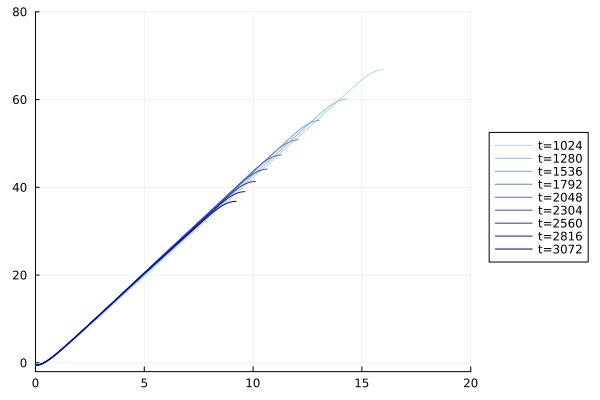

In [83]:
# which_ind(t) = t==0 ? 1 : t==1 ? 2 : t÷10+2
which_ind(t) = t÷10 + 1

p = 0.1

L = 512
T = 10L

ts = 4L÷2:L÷2:6L

colors = palette(:blues, length(ts))
plt = plot()
for (i, t) in enumerate(ts)
    ind = which_ind(t)
    xs = collect(1:2:L)
    xs /= sqrt(t)
    ys = reverse(combined[(L=L, T=T, p=p, mode="renyi2", t=1)][:κ2_corrs][ind, :] )
    ys = t * (-log.(exp(1.382)*ys) / sqrt(t)) 
    plot!(plt, xs, ys, label="t=$t",legend=:outerright,color=colors[i], xlims=(0,20), ylims=(-2,80))
end
plt

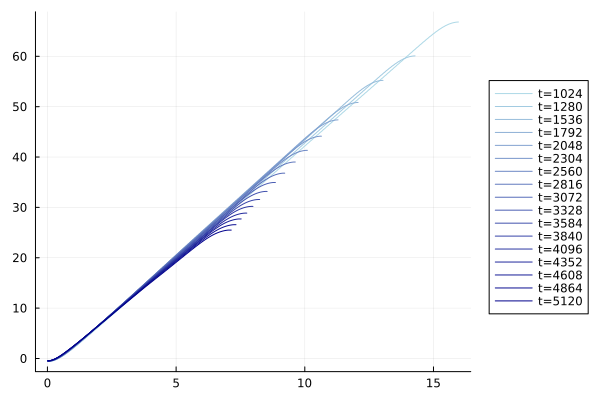

In [127]:
# which_ind(t) = t==0 ? 1 : t==1 ? 2 : t÷10+2
which_ind(t) = t÷10 + 1

p = 0.1

L = 512
T = 10L

ts = 4L÷2:L÷2:10L

colors = palette(:blues, length(ts))
plt = plot()
for (i, t) in enumerate(ts)
    ind = which_ind(t)
    xs = collect(1:2:L)
    xs /= sqrt(t)
    ys = reverse(combined[(L=L, T=T, p=p, mode="renyi2", t=1)][:κ2_corrs][ind, :] )
    ys = t * (-log.(exp(1.382)*ys) / sqrt(t) ) 
    plot!(plt, xs, ys, label="t=$t",legend=:outerright,color=colors[i])#, xlims=(0,20), ylims=(-2,80))
end
plt

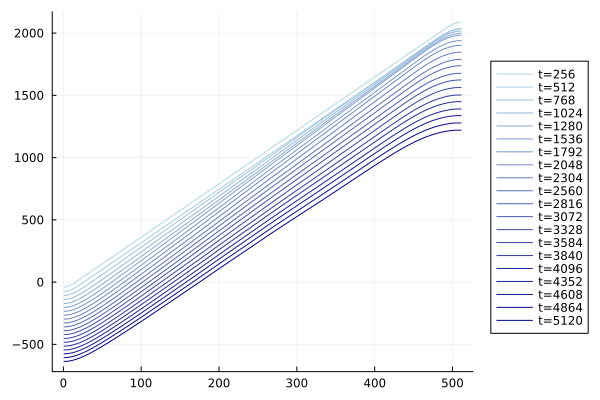

In [131]:
# which_ind(t) = t==0 ? 1 : t==1 ? 2 : t÷10+2
which_ind(t) = t÷10 + 1

p = 0.1

L = 512
T = 10L

ts = L÷2:L÷2:10L

colors = palette(:blues, length(ts))
plt = plot()
for (i, t) in enumerate(ts)
    ind = which_ind(t)
    xs = collect(1:2:L)
    # xs /= sqrt(t)
    ys = reverse(combined[(L=L, T=T, p=p, mode="renyi2", t=1)][:κ2_corrs][ind, :] )
    ys = t * (-log.(exp(1.5)*ys)) 
    plot!(plt, xs, ys, label="t=$t",legend=:outerright,color=colors[i])#, xlims=(0,20), ylims=(-2,80))
end
plt

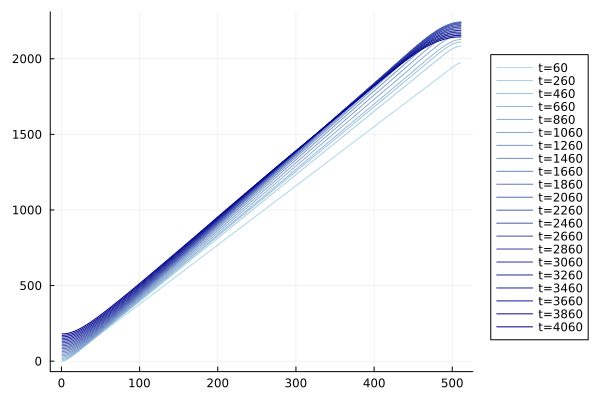

In [201]:
# which_ind(t) = t==0 ? 1 : t==1 ? 2 : t÷10+2
which_ind(t) = t÷10 + 1

p = 0.1

L = 512
T = 10L

ts = 60:200:8L

colors = palette(:blues, length(ts))
plt = plot()
for (i, t) in enumerate(ts)
    ind = which_ind(t)
    # xs = collect(1:2:L)
    xs = collect(1:2:L)#sqrt(t))))
    # xs /= sqrt(t)
    ys = reverse(combined[(L=L, T=T, p=p, mode="renyi2", t=1)][:κ2_corrs][ind, :] )
    ys =  t*(-log.(exp(1.33)*ys))#/sqrt(t)) 
    plot!(plt, xs, ys[1:length(xs)], label="t=$t",legend=:outerright,color=colors[i])#, xlims=(0,20), ylims=(-2,80))
end
plt

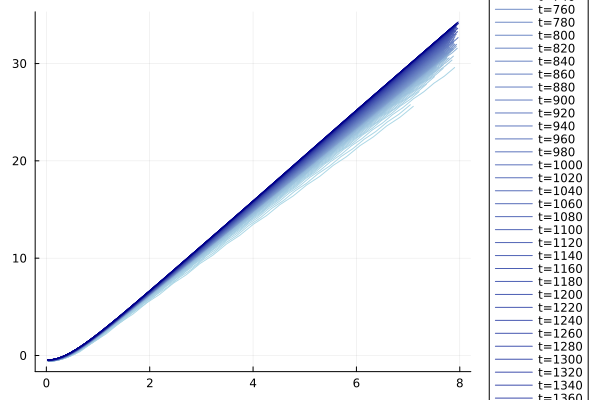

In [318]:
# which_ind(t) = t==0 ? 1 : t==1 ? 2 : t÷10+2
which_ind(t) = t÷10 + 1

p = 0.1

L = 512
T = 10L

ts = 60:20:4L

colors = palette(:blues, length(ts))
plt = plot()
for (i, t) in enumerate(ts)
    ind = which_ind(t)
    # xs = collect(1:2:L)
    xs = collect(1:2:8Int(floor(sqrt(t))))
    xs /= sqrt(t)
    ys = reverse(combined[(L=L, T=T, p=p, mode="renyi2", t=1)][:κ2_corrs][ind, :] )
    ys =  t*(-log.(exp(1.38)*ys)/sqrt(t)) 
    plot!(plt, xs, ys[1:length(xs)], label="t=$t",legend=:outerright,color=colors[i])#, xlims=(0,20), ylims=(-2,80))
end
plt

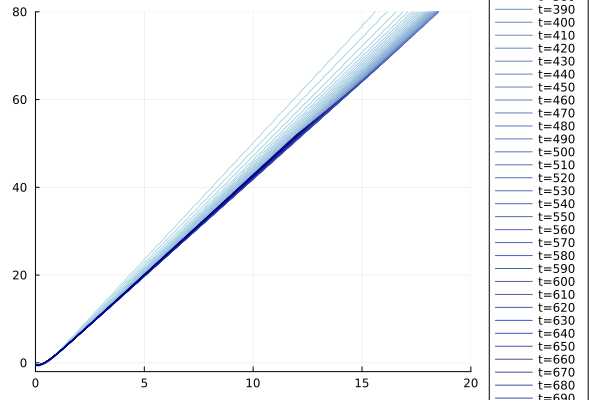

In [361]:
# which_ind(t) = t==0 ? 1 : t==1 ? 2 : t÷10+2
which_ind(t) = t÷10 + 1

p = 0.1

L = 512
T = 10L

ts = 50:10:2L

colors = palette(:blues, length(ts))
plt = plot()
for (i, t) in enumerate(ts)
    ind = which_ind(t)
    # xs = collect(1:2:L)
    xs = collect(1:2:3L÷4)
    xs /= sqrt(t)
    ys = reverse(combined[(L=L, T=T, p=p, mode="renyi2", t=1)][:κ2_corrs][ind, :] )
    ys =  (t+18.77888973860926)*(-log.(exp(1.38)*ys)/sqrt(t)) 
    plot!(plt, xs, ys[1:length(xs)], label="t=$t",legend=:outerright,color=colors[i], xlims=(0,20), ylims=(-2,80))
end
plt

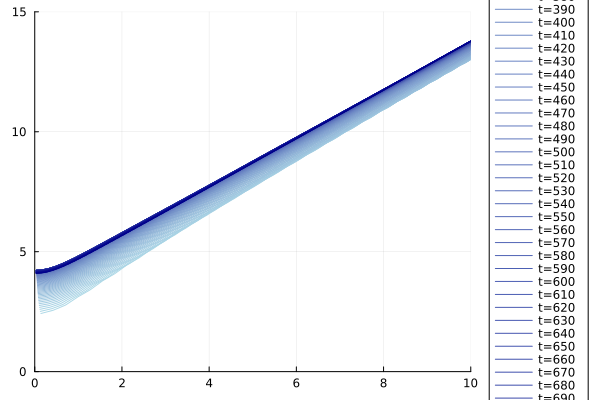

In [410]:
# which_ind(t) = t==0 ? 1 : t==1 ? 2 : t÷10+2
which_ind(t) = t÷10 + 1

p = 0.1

L = 512
T = 10L

ts = 50:10:2L

colors = palette(:blues, length(ts))
plt = plot()
for (i, t) in enumerate(ts)
    ind = which_ind(t)
    # xs = collect(1:2:L)
    xs = collect(1:2:3L÷4)
    xs /= sqrt(t)
    ys = reverse(combined[(L=L, T=T, p=p, mode="renyi2", t=1)][:κ2_corrs][ind, :] )
    ys = (-log.(ys)/sqrt(t) .- 0.025) * (β[1]*t+β[2])
    plot!(plt, xs, ys[1:length(xs)], label="t=$t",legend=:outerright,color=colors[i], xlims=(0,10), ylims=(0,15))
end
plt

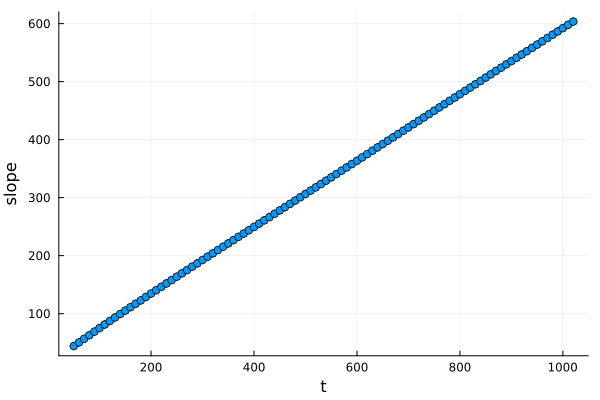

In [378]:
p = 0.1
L = 512
T = 10L
ts = 50:10:2L

slopes = Float64[]
for t in ts
    ind = which_ind(t)
    xs = collect(1:2:L)/sqrt(t)
    ys_raw = reverse(combined[(L=L, T=T, p=p, mode="renyi2", t=1)][:κ2_corrs][ind, :])
    ys = -log.(ys_raw)/sqrt(t)

    mask = (xs .>= 1) .& (xs .<= 3L/4/sqrt(t))
    X = hcat(xs[mask], ones(sum(mask)))
    γ = X \ ys[mask]          # [slope, intercept]
    push!(slopes, 1/γ[2]^2)
end

plot(ts, slopes; xlabel="t", ylabel="slope", marker=:o, legend=false)

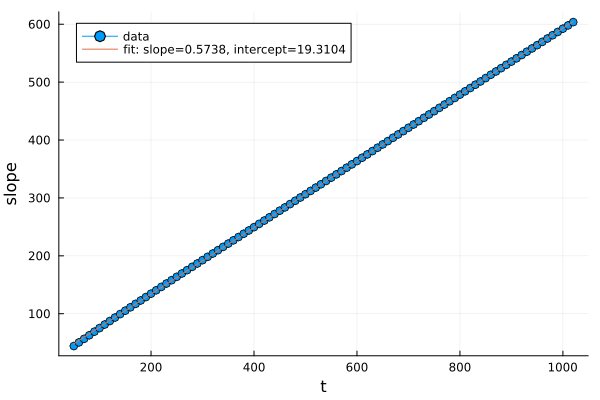

In [379]:
ts = 50:10:2L
X = hcat(ts, ones(length(ts)))
γ = X \ slopes  # [slope, intercept]
fit_line = X * γ

plot(ts, slopes; xlabel="t", ylabel="slope", marker=:o, label="data")
plot!(ts, fit_line; label="fit: slope=$(round(γ[1], digits=4)), intercept=$(round(γ[2], digits=4))")

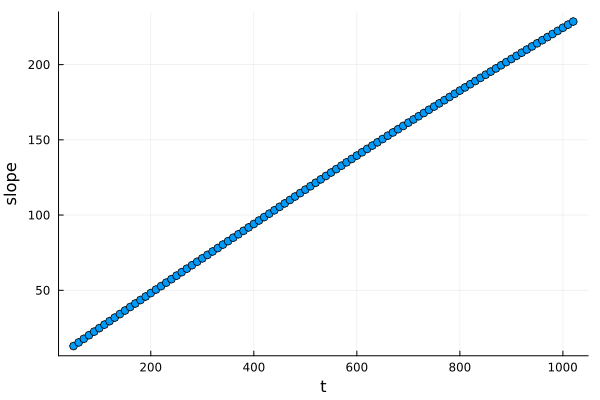

In [380]:
p = 0.1
L = 512
T = 10L
ts = 50:10:2L

slopes = Float64[]
for t in ts
    ind = which_ind(t)
    xs = collect(1:2:L)/sqrt(t)
    ys_raw = reverse(combined[(L=L, T=T, p=p, mode="renyi2", t=1)][:κ2_corrs][ind, :])
    ys = -log.(ys_raw)/sqrt(t)

    mask = (xs .>= 1) .& (xs .<= 3L/4/sqrt(t))
    X = hcat(xs[mask], ones(sum(mask)))
    β = X \ ys[mask]          # [slope, intercept]
    push!(slopes, 1/β[1])
end

plot(ts, slopes; xlabel="t", ylabel="slope", marker=:o, legend=false)

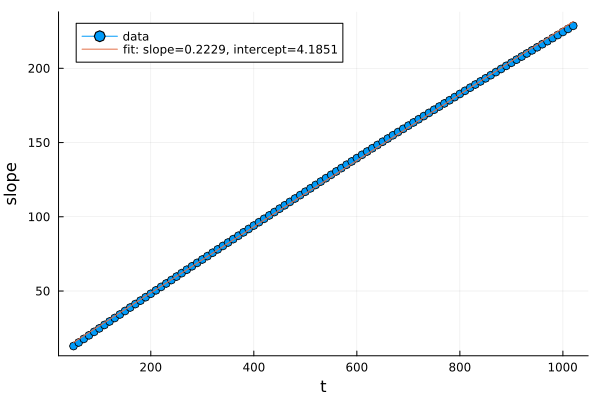

In [381]:
ts = 50:10:2L
X = hcat(ts, ones(length(ts)))
β = X \ slopes  # [slope, intercept]
fit_line = X * β

plot(ts, slopes; xlabel="t", ylabel="slope", marker=:o, label="data")
plot!(ts, fit_line; label="fit: slope=$(round(β[1], digits=4)), intercept=$(round(β[2], digits=4))")

In [360]:
β[2]/β[1]

18.77888973860926

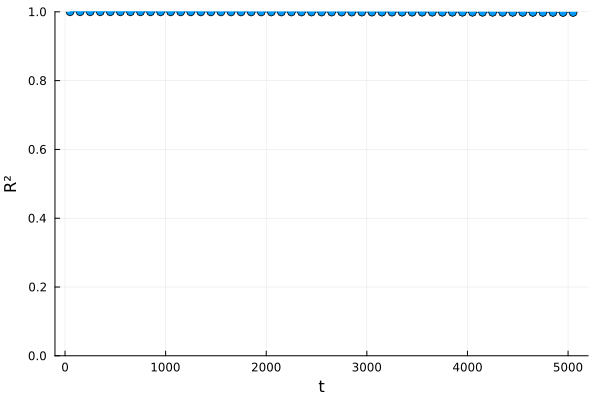

In [ ]:
r2s = Float64[]
for t in ts
    ind = which_ind(t)
    xs = collect(1:2:L)
    ys_raw = reverse(combined[(L=L, T=T, p=p, mode="renyi2", t=1)][:κ2_corrs][ind, :])
    ys = -log.(ys_raw)

    mask = (xs .>= sqrt(t)) .& (xs .<= 3L/4)
    X = hcat(xs[mask], ones(sum(mask)))
    β = X \ ys[mask]

    ŷ = X * β
    ss_res = sum((ys[mask] .- ŷ).^2)
    ss_tot = sum((ys[mask] .- mean(ys[mask])).^2)
    push!(r2s, 1 - ss_res / ss_tot)
end

plot(ts, r2s; xlabel="t", ylabel="R²", ylim=(0,1), marker=:o, legend=false)

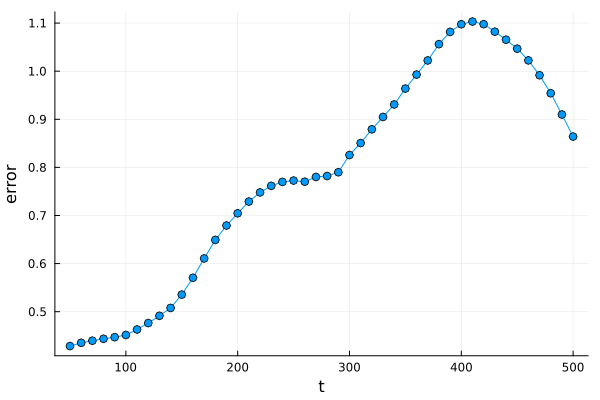

In [335]:
# which_ind(t) = t==0 ? 1 : t==1 ? 2 : t÷10+2
which_ind(t) = t÷10 + 1

p = 0.1

L = 512
T = 10L

ts = 50:10:500

# colors = palette(:blues, length(ts))
# plt = plot()
# for (i, t) in enumerate(ts)
#     ind = which_ind(t)
#     # xs = collect(1:2:L)
#     xs = collect(1:2:L)#sqrt(t))))
#     # xs /= sqrt(t)
#     ys = reverse(combined[(L=L, T=T, p=p, mode="renyi2", t=1)][:κ2_corrs][ind, :] )
#     ys =  t*(-log.(exp(1.33)*ys))#/sqrt(t)) 
#     plot!(plt, xs, ys[1:length(xs)], label="t=$t",legend=:outerright,color=colors[i])#, xlims=(0,20), ylims=(-2,80))
# end
# plt

errors = Float64[]
for t in ts
    ind = which_ind(t)
    xs = collect(1:2:L)
    ys_raw = reverse(combined[(L=L, T=T, p=p, mode="renyi2", t=1)][:κ2_corrs][ind, :])
    ys = -log.(ys_raw)

    mask = (xs .>= 20) .& (xs .<= 0.8L)
    X = hcat(xs[mask], ones(sum(mask)))
    β = X \ ys[mask]

    residuals = t*(ys[mask] .- X * β)
    push!(errors, maximum(abs.(residuals)))

    # println(maximum(abs.(residuals)))

    # plot!(plt, xs, t * (X * β .- 1.33))
end
# plt
plot(ts, errors; xlabel="t", ylabel="error", marker=:o, legend=false)

In [232]:
println(r2s)

[0.9999967770595788, 0.9999849799792229, 0.9999682299020975, 0.999949196502116, 0.999930782912662, 0.9999111731223393, 0.9998875686167866, 0.9998611475051075, 0.9998321388679061, 0.999800698436897, 0.9997673747783099, 0.9997323948872368, 0.9996959408844609, 0.999658784002771, 0.9996211830401623, 0.9995832287518235, 0.9995448165842551, 0.9995058800227677, 0.9994661311593819, 0.99942587270101, 0.9993852848307136, 0.9993444784552524, 0.999303428336166, 0.9992618199214451, 0.9992199168433499, 0.9991776797585845, 0.9991351152825867, 0.9990919755851186, 0.9990479277354504, 0.9990024673143912, 0.9989556048762973, 0.9989075626171993, 0.9988584744591675, 0.9988083493560407, 0.9987574205492984, 0.9987057490509438, 0.9986527930510445, 0.9985979289554575, 0.9985422965926193, 0.998485732469312, 0.9984280794325402, 0.9983697211174367, 0.9983105932678079, 0.998250196413876, 0.9981882203179306, 0.9981245708014371, 0.9980598652014719, 0.9979937739093594, 0.9979264226290187, 0.997858127048604, 0.9977896

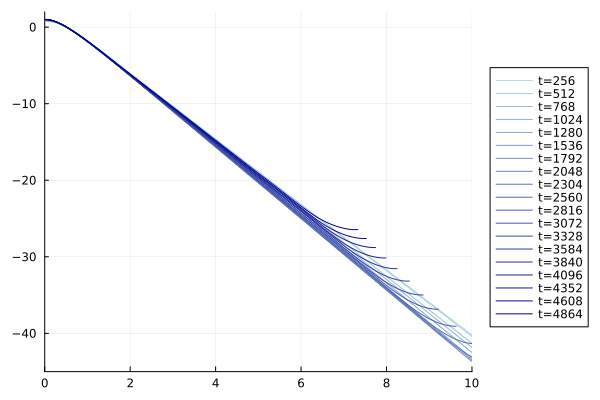

In [28]:
which_ind(t) = t==0 ? 1 : t==1 ? 2 : t÷10+2

p = 0.1

L = 512
T = 10L

ts = L÷2:L÷2:T-L÷2

colors = palette(:blues, length(ts))
plt = plot()
for (i, t) in enumerate(ts)
    ind = which_ind(t)
    xs = collect(1:2:L)
    xs /= sqrt(t)
    ys = reverse(combined[(L=L, T=T, p=p, mode="renyi2", t=1)][:κ2_corrs][ind, :] )
    ys = sqrt(t)*log.(exp(1.39)*ys)
    plot!(plt, xs, ys, label="t=$t",legend=:outerright,color=colors[i], xlim=(0,10), ylim=(-45,2))
end
plt